# Indoor Campus Radio Environment with Sionna RT

This notebook turns the supplied two-storey campus model into a reproducible Sionna RT experiment. You will:

- load the prepared 2.4 GHz or 923 MHz scene;
- inspect a clipped floor view without removing the physical ceiling;
- place physically plausible access-point candidates;
- compute an optional radio map at device height; and
- screen candidate sites with a simple coverage objective.

The geometry is already a **3D radio environment**. It becomes a radio digital twin after its material parameters and predictions are calibrated against measurements.

## 1. Imports and repository discovery

The campus assets live in `sionna-lora-ext/assets`. The search below makes the notebook work when Jupyter starts from the workspace root, the repository root, or the tutorial directory.

In [4]:
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from sionna.rt import Camera, PlanarArray, RadioMapSolver, Transmitter, load_scene


def find_repo_root(start=Path.cwd()):
    for parent in (start, *start.parents):
        for candidate in (parent, parent / "sionna-lora-ext"):
            if (candidate / "assets" / "sionna" / "scene_2400MHz.xml").is_file():
                return candidate
    raise FileNotFoundError(
        "Could not find sionna-lora-ext/assets/sionna/scene_2400MHz.xml. "
        "Start Jupyter from the workspace, repository, or tutorial directory."
    )


REPO_ROOT = find_repo_root()
ASSETS_DIR = REPO_ROOT / "assets"

# Check the three supported Jupyter starting directories.
for start in (REPO_ROOT.parent, REPO_ROOT, REPO_ROOT / "tutorials" / "rt-campus"):
    assert find_repo_root(start) == REPO_ROOT

print("Repository:", REPO_ROOT)
print("Sionna:", version("sionna"), "Sionna RT:", version("sionna-rt"))

Repository: /home/ubuntu/Desktop/sk/nvidia/sionna-lora-ext
Sionna: 2.1.0 Sionna RT: 2.1.0


## 2. Experiment parameters

The exported materials are prepared only for 2.4 GHz and 923 MHz. Use the matching scene rather than changing the carrier frequency on a scene prepared for the other band.

`device_z` represents a handheld device about 1.3 m above its floor. Change it to the measured antenna height for a laptop, sensor, or robot.

In [5]:
FREQUENCY_HZ = 2.4e9  # alternatively 923e6
ACTIVE_FLOOR = "F2"

FLOORS = {
    "F1": {
        "floor_z": -1.4370243549,
        "ceiling_z": 1.5994563103,
        "device_z": -0.14,
        "ap_z": 1.35,
        "clip_z": 0.80,
    },
    "F2": {
        "floor_z": 2.5087316036,
        "ceiling_z": 5.5500001907,
        "device_z": 3.81,
        "ap_z": 5.30,
        "clip_z": 5.20,
    },
}

# Static rendering and radio-map computation are opt-in. The preview is lightweight.
RENDER_STATIC = False
OPEN_INTERACTIVE_PREVIEW = True
RUN_RADIO_MAP = True

floor = FLOORS[ACTIVE_FLOOR]
assert FREQUENCY_HZ in (2.4e9, 923e6)
assert floor["floor_z"] < floor["device_z"] < floor["ap_z"] < floor["ceiling_z"]

## 3. Load and validate the scene

Objects sharing an RF material are merged during loading. This reduces the scene from 952 exported meshes to 47 ray-tracing objects without changing their geometry.

In [15]:
scene_filename = {2.4e9: "scene_2400MHz.xml", 923e6: "scene_923MHz.xml"}[FREQUENCY_HZ]
scene = load_scene(str(ASSETS_DIR / "sionna" / scene_filename), merge_shapes=True)
scene.frequency = FREQUENCY_HZ
bbox = scene.mi_scene.bbox()
bbox_min = np.asarray(bbox.min)
bbox_max = np.asarray(bbox.max)

print(f"Loaded {len(scene.objects)} merged objects and {len(scene.radio_materials)} materials")
print("Bounds [m]:", bbox_min, "to", bbox_max)
print("Frequency [GHz]:", FREQUENCY_HZ / 1e9)

Loaded 62 merged objects and 62 materials
Bounds [m]: [-68.73138    -9.383204   -1.4727671] to [ 4.3785686 61.24646   10.03883  ]
Frequency [GHz]: 2.4


## 4. Inspect the enclosed building

Keep the ceiling, roof, and interfloor slab in the propagation model. They determine penetration loss and cross-floor interference. Use a rendering clip plane to see inside instead of deleting geometry.

The saved reference render is displayed immediately. Enable static rendering when you want a new camera view. The interactive `scene.preview()` appears after the AP candidates are added below.

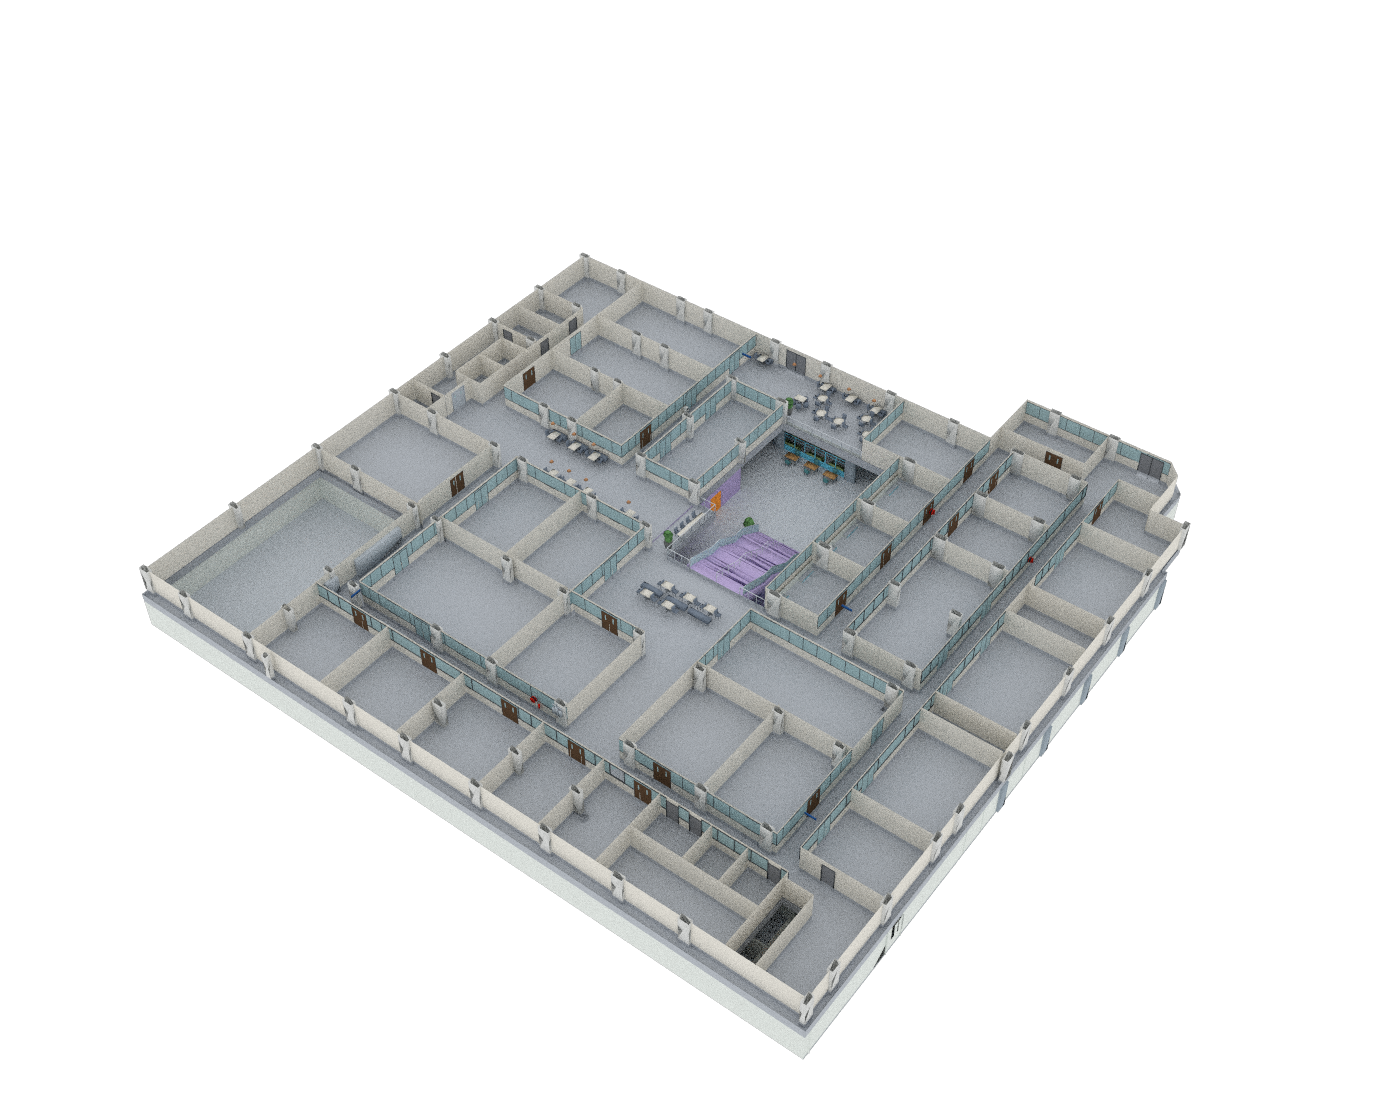

In [16]:
reference_render = ASSETS_DIR / "sionna-render.png"
if reference_render.is_file():
    display(Image(filename=str(reference_render), width=900))
else:
    print("Reference render not found; set RENDER_STATIC=True to create a live view.")

In [8]:
camera = Camera(position=[36, -64, 112], look_at=[-32, 26, 2])

if RENDER_STATIC:
    scene.render(
        camera=camera,
        clip_at=floor["clip_z"],
        resolution=(1000, 800),
        num_samples=64,
        show_devices=False,
    )

## 5. Define physically constrained AP candidates

AP placement should begin with feasible mounting sites, not unconstrained random points. The candidates below cover north, south, east, and west circulation areas. They are intentionally a small starting set. Use the GUI or preview point picker to move them onto verified ceiling or wall-mount locations with power and backhaul access.

For a deployment study, expand this list with room-specific candidates and record why every position is installable.

In [9]:
AP_CANDIDATES = {
    "F1": {
        "f1_library": (-11.0, 26.0),
        "f1_central_foyer": (-29.0, 24.0),
        "f1_west_rooms": (-51.0, 31.0),
        "f1_south_lecture": (-42.0, 8.0),
    },
    "F2": {
        "f2_east_corridor": (-15.5, 25.5),
        "f2_west_corridor": (-49.0, 25.0),
        "f2_north_corridor": (-33.0, 49.0),
        "f2_south_corridor": (-31.0, 5.0),
    },
}

active_candidates = {
    name: np.array([x, y, floor["ap_z"]], dtype=float)
    for name, (x, y) in AP_CANDIDATES[ACTIVE_FLOOR].items()
}

assert len(active_candidates) == len(set(active_candidates))
assert all(bbox_min[0] <= p[0] <= bbox_max[0] for p in active_candidates.values())
assert all(bbox_min[1] <= p[1] <= bbox_max[1] for p in active_candidates.values())
assert all(floor["floor_z"] < p[2] < floor["ceiling_z"] for p in active_candidates.values())
active_candidates

{'f2_east_corridor': array([-15.5,  25.5,   5.3]),
 'f2_west_corridor': array([-49. ,  25. ,   5.3]),
 'f2_north_corridor': array([-33. ,  49. ,   5.3]),
 'f2_south_corridor': array([-31. ,   5. ,   5.3])}

In [10]:
# Isotropic antennas form a neutral placement baseline. Replace them with
# measured AP patterns before drawing deployment conclusions.
scene.tx_array = PlanarArray(
    num_rows=1, num_cols=1, pattern="iso", polarization="V"
)
scene.rx_array = PlanarArray(
    num_rows=1, num_cols=1, pattern="iso", polarization="V"
)

# Make this cell safe to re-run.
for name in list(scene.transmitters):
    scene.remove(name)

for name, position in active_candidates.items():
    scene.add(Transmitter(name=name, position=position, power_dbm=20.0))

print("Added AP candidates:", list(scene.transmitters))

Added AP candidates: ['f2_east_corridor', 'f2_west_corridor', 'f2_north_corridor', 'f2_south_corridor']


In [11]:
if OPEN_INTERACTIVE_PREVIEW:
    scene.preview(
        clip_at=floor["clip_z"],
        resolution=(1100, 800),
        show_devices=True,
        show_orientations=True,
        point_picker=True,
    )
else:
    print("Set OPEN_INTERACTIVE_PREVIEW=True to inspect and refine AP positions.")